# ERC Dynamic Accessibility Lattice (DAL)

### Fixed scaffold, dynamic traversability

**Exploratory computational note**

---

## Objective

This notebook explores whether a system may preserve structural scaffold while progressively reorganizing which futures remain operationally accessible under perturbation–recovery constraints.

The central working hypothesis is:

> the scaffold may persist while effective accessibility changes.

Rather than abrupt disconnection, the notebook tests whether perturbation timing, recovery kinetics, and perturbation history progressively reshape reachable futures and accessibility cost.

The notebook is exploratory and falsification-oriented.

No claim is made regarding universal physical mechanisms.

---

## Short summary

This notebook explores whether systems may preserve structural scaffold while progressively reorganizing operational accessibility under perturbation–recovery constraints.

Through repeated perturbation, timing manipulation, recovery heterogeneity, robustness tests, and falsification-oriented controls, we evaluate whether accessibility organization emerges operationally without requiring structural disconnection.

In [41]:
# ============================================================
# ERC Dynamic Accessibility Lattice (DAL)
# Fixed scaffold, dynamic traversability
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path

PROJECT_ROOT = Path.cwd()

FIG_DIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "tables"
DOC_DIR = PROJECT_ROOT / "docs"

for folder in [FIG_DIR, DATA_DIR, DOC_DIR]:
    folder.mkdir(exist_ok=True)

print("Dynamic Accessibility Lattice notebook ready")

Dynamic Accessibility Lattice notebook ready


Nodes: 144
Edges: 264


/tmp/ipykernel_3139/1415541910.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


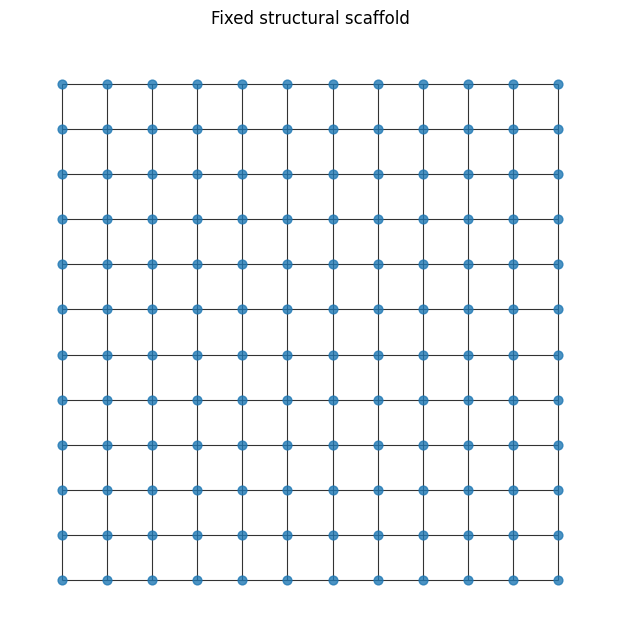

In [42]:
# ============================================================
# Fixed scaffold: 2D lattice graph
# ============================================================

GRID_SIZE = 12

G = nx.grid_2d_graph(GRID_SIZE, GRID_SIZE)

# Convert node labels to integers for easier matrix handling
G = nx.convert_node_labels_to_integers(G)

pos = {
    node: (node % GRID_SIZE, node // GRID_SIZE)
    for node in G.nodes()
}

N = G.number_of_nodes()
E = G.number_of_edges()

print("Nodes:", N)
print("Edges:", E)

plt.figure(figsize=(6, 6))
nx.draw(
    G,
    pos,
    node_size=40,
    width=0.8,
    alpha=0.8
)
plt.title("Fixed structural scaffold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fixed_structural_scaffold.png", dpi=300)
plt.show()

In [43]:
# ============================================================
# Dynamic accessibility state
# ============================================================

def initialize_state(N):
    return {
        "r": np.ones(N),       # local recoverability / capacity
        "D": np.zeros(N),      # local accumulated damage / burden
    }


def edge_traversability(G, r, D):
    """
    Effective traversability of each structural edge.
    Scaffold remains fixed; traversability changes.
    """
    weights = {}

    for u, v in G.edges():
        local_capacity = 0.5 * (r[u] + r[v])
        local_burden = 0.5 * (D[u] + D[v])

        w = local_capacity / (1 + local_burden)
        weights[(u, v)] = w

    return weights

In [44]:
# ============================================================
# Perturbation and recovery dynamics
# ============================================================

def perturbation_profile(G, center_node, radius=2):
    """
    Spatial perturbation centered on a node.
    """
    lengths = nx.single_source_shortest_path_length(
        G,
        center_node,
        cutoff=radius
    )

    affected = np.zeros(G.number_of_nodes())

    for node, dist in lengths.items():
        affected[node] = np.exp(-dist)

    return affected


def update_state(
    state,
    perturbation,
    alpha=0.20,
    beta=0.08,
    gamma=0.04,
    decay=0.03,
    dt=1.0
):
    """
    r decreases with perturbation and damage.
    D accumulates under perturbation but slowly decays.
    """

    r = state["r"].copy()
    D = state["D"].copy()

    dr = (
        -alpha * perturbation
        + beta * (1 - r)
        - gamma * D
    )

    dD = (
        perturbation
        - decay * D
    )

    r = np.clip(r + dr * dt, 0, 1)
    D = np.clip(D + dD * dt, 0, None)

    return {
        "r": r,
        "D": D
    }

## Baseline dynamic accessibility simulation

We first simulate repeated perturbation under a fixed scaffold to test whether effective accessibility may progressively reorganize while structural connectivity remains preserved.

Question:

> Can a system remain connected while progressively changing which futures remain operationally reachable?

In [45]:
# ============================================================
# Effective accessibility metrics
# ============================================================

def effective_graph(G, weights, threshold=0.35):
    """
    Keep only edges whose traversability exceeds threshold.
    """
    Ge = nx.Graph()
    Ge.add_nodes_from(G.nodes())

    for (u, v), w in weights.items():
        if w >= threshold:
            Ge.add_edge(u, v, weight=w)

    return Ge


def accessibility_metrics(G, Ge, source=0):
    """
    Compare structural scaffold vs effective traversability graph.
    """
    structural_reachable = len(nx.node_connected_component(G, source))

    if source in Ge:
        effective_reachable = len(nx.node_connected_component(Ge, source))
    else:
        effective_reachable = 0

    return {
        "structural_reachable": structural_reachable,
        "effective_reachable": effective_reachable,
        "accessible_fraction": effective_reachable / structural_reachable,
        "effective_edges": Ge.number_of_edges(),
        "structural_edges": G.number_of_edges(),
        "edge_fraction": Ge.number_of_edges() / G.number_of_edges(),
    }

In [46]:
# ============================================================
# Simulate dynamic accessibility under repeated perturbation
# Stress-test version
# ============================================================

T = 100

center_node = N // 2
source_node = 0

# More frequent perturbations relative to recovery
perturbation_times = [10, 15, 20, 25, 30]

# Stronger perturbation
perturbation_strength = 3.0

# More restrictive effective traversability threshold
ACCESS_THRESHOLD = 0.65

state = initialize_state(N)

records = []
states_over_time = {}

for t in range(T):

    if t in perturbation_times:
        P = perturbation_strength * perturbation_profile(
            G,
            center_node=center_node,
            radius=3
        )
    else:
        P = np.zeros(N)

    # Slower recovery, stronger damage coupling, slower damage decay
    state = update_state(
        state,
        P,
        alpha=0.20,
        beta=0.03,
        gamma=0.12,
        decay=0.01,
        dt=1.0
    )

    weights = edge_traversability(
        G,
        state["r"],
        state["D"]
    )

    Ge = effective_graph(
        G,
        weights,
        threshold=ACCESS_THRESHOLD
    )

    metrics = accessibility_metrics(
        G,
        Ge,
        source=source_node
    )

    records.append({
        "time": t,
        **metrics,
        "mean_r": np.mean(state["r"]),
        "mean_D": np.mean(state["D"]),
        "min_r": np.min(state["r"]),
        "max_D": np.max(state["D"]),
    })

    if t in [0, 10, 20, 30, 45, 70, 95]:
        states_over_time[t] = {
            "r": state["r"].copy(),
            "D": state["D"].copy(),
            "Ge": Ge.copy(),
        }

dan_df = pd.DataFrame(records)

dan_df.to_csv(
    DATA_DIR / "dynamic_accessibility_network_summary_stress.csv",
    index=False
)

dan_df.head()

,time,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,mean_r,mean_D,min_r,max_D
0,0,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0
1,1,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0
2,2,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0
3,3,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0
4,4,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0


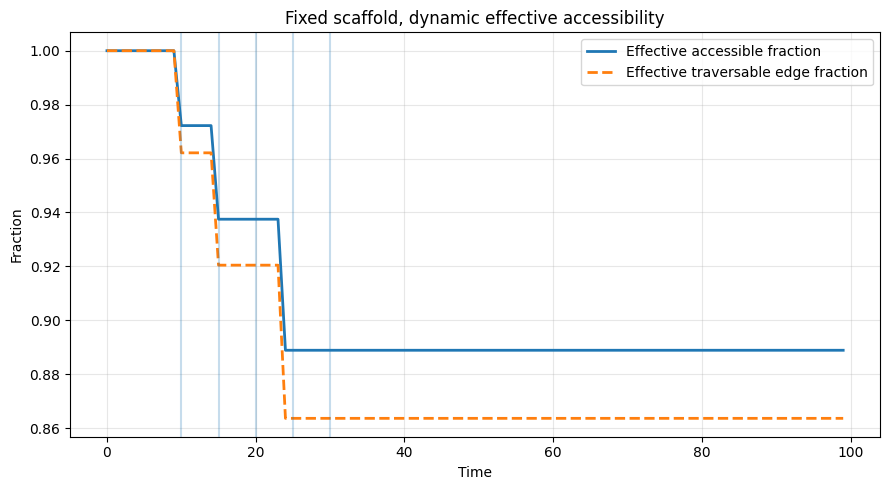

In [47]:
# ============================================================
# Plot accessibility contraction while scaffold persists
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    dan_df["time"],
    dan_df["accessible_fraction"],
    linewidth=2,
    label="Effective accessible fraction"
)

plt.plot(
    dan_df["time"],
    dan_df["edge_fraction"],
    linewidth=2,
    linestyle="--",
    label="Effective traversable edge fraction"
)

for pt in perturbation_times:
    plt.axvline(pt, alpha=0.25)

plt.xlabel("Time")
plt.ylabel("Fraction")
plt.title("Fixed scaffold, dynamic effective accessibility")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fixed_scaffold_dynamic_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Perturbation timing and reachable futures

We next test whether identical perturbation magnitude but different temporal delivery reorganizes operational accessibility.

Question:

> Does timing alone reshape reachable futures under the same total perturbation?

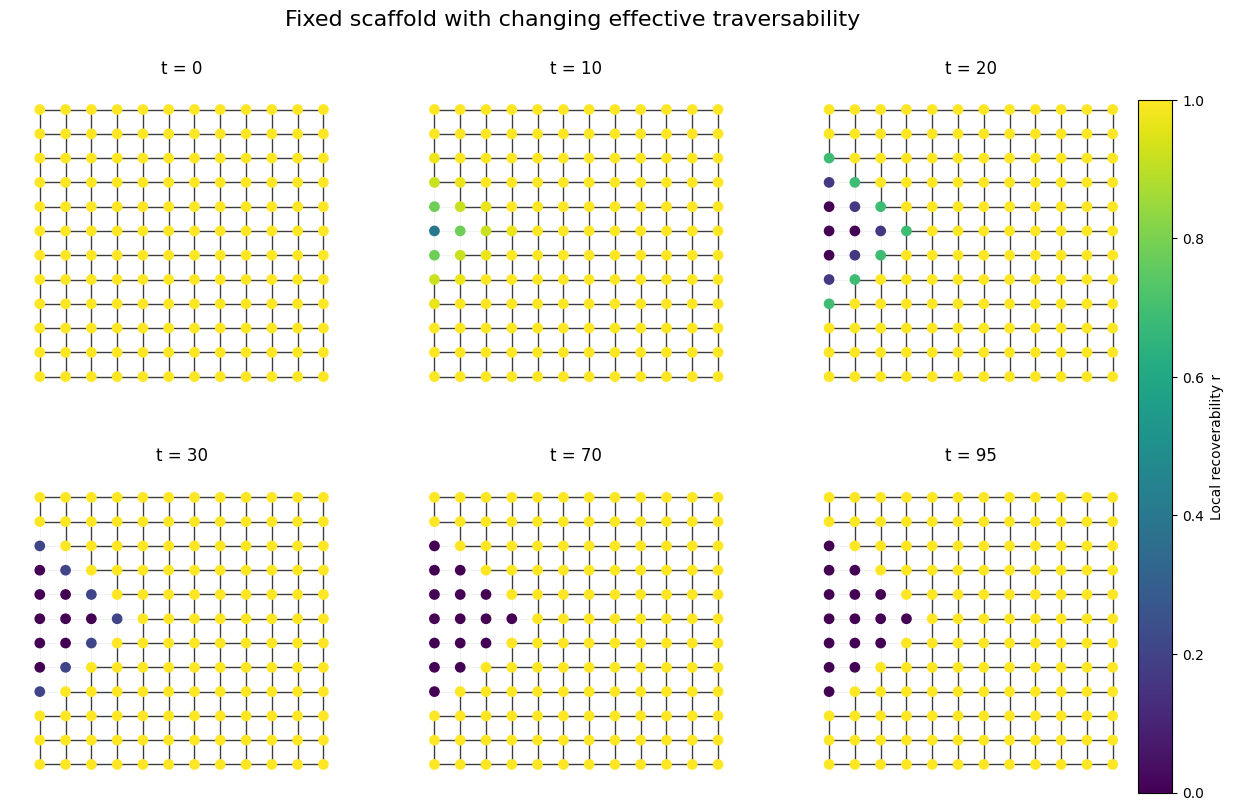

In [48]:
# ============================================================
# Visual snapshots: fixed scaffold, changing traversability
# Clean layout version
# ============================================================

snapshot_times = [0, 10, 20, 30, 70, 95]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, t_snapshot in zip(axes, snapshot_times):

    snapshot = states_over_time[t_snapshot]

    r = snapshot["r"]
    Ge = snapshot["Ge"]

    # --------------------------------------------------------
    # Draw full structural scaffold in light gray
    # --------------------------------------------------------
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="lightgray",
        width=0.6,
        alpha=0.35
    )

    # --------------------------------------------------------
    # Draw effective traversable edges in black
    # --------------------------------------------------------
    nx.draw_networkx_edges(
        Ge,
        pos,
        ax=ax,
        edge_color="black",
        width=1.0,
        alpha=0.75
    )

    # --------------------------------------------------------
    # Draw nodes colored by local recoverability
    # --------------------------------------------------------
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=r,
        cmap="viridis",
        vmin=0,
        vmax=1,
        node_size=45
    )

    ax.set_title(f"t = {t_snapshot}")
    ax.axis("off")

fig.suptitle(
    "Fixed scaffold with changing effective traversability",
    fontsize=16
)

# ------------------------------------------------------------
# Clean colorbar placement
# ------------------------------------------------------------
cbar = fig.colorbar(
    nodes,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Local recoverability r")

plt.subplots_adjust(
    right=0.88,
    wspace=0.15,
    hspace=0.20,
    top=0.90
)

plt.savefig(
    FIG_DIR / "dynamic_accessibility_scaffold_snapshots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

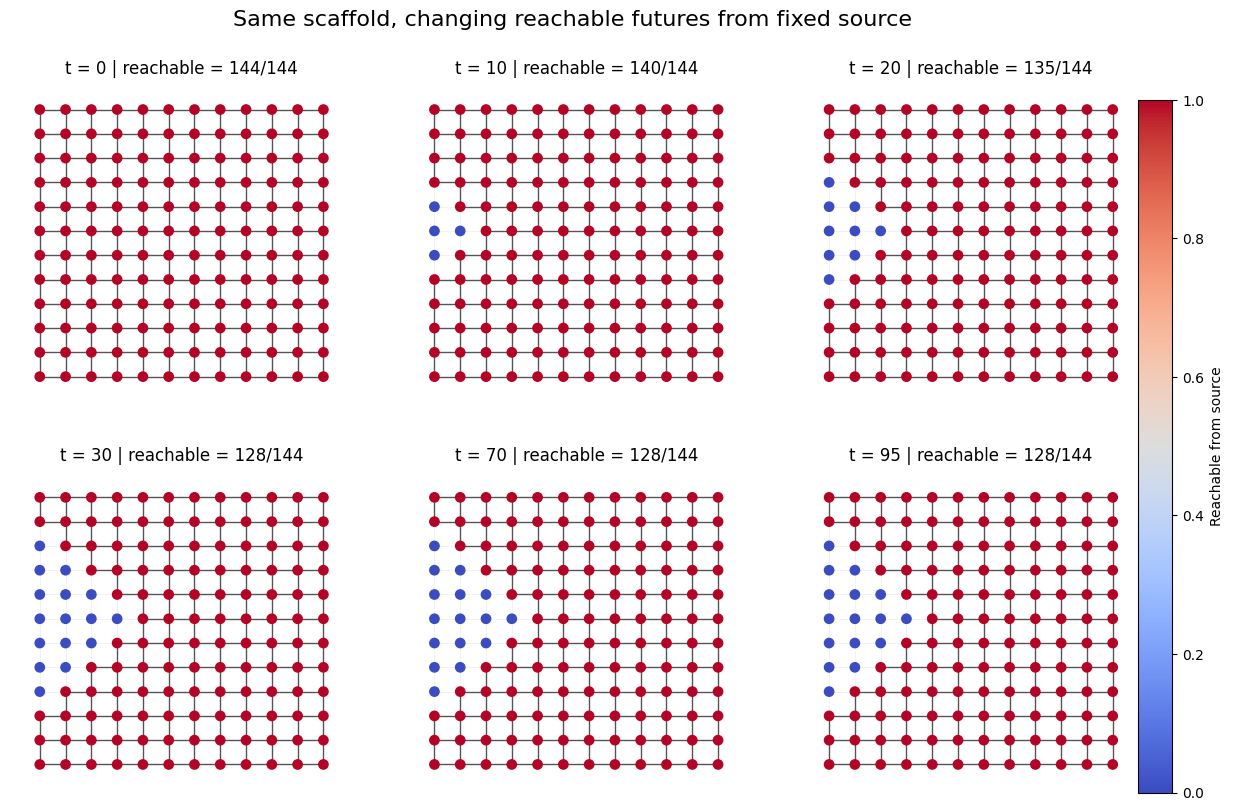

In [49]:
# ============================================================
# Reachability snapshots from a fixed source
# Same scaffold, changing reachable futures
# ============================================================

source_node = 0
snapshot_times = [0, 10, 20, 30, 70, 95]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, t_snapshot in zip(axes, snapshot_times):

    snapshot = states_over_time[t_snapshot]
    Ge = snapshot["Ge"]

    # Nodes reachable from source in effective graph
    if source_node in Ge:
        reachable_nodes = set(
            nx.node_connected_component(Ge, source_node)
        )
    else:
        reachable_nodes = set()

    node_colors = [
        1 if node in reachable_nodes else 0
        for node in G.nodes()
    ]

    # Draw full scaffold
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="lightgray",
        width=0.6,
        alpha=0.35
    )

    # Draw effective edges
    nx.draw_networkx_edges(
        Ge,
        pos,
        ax=ax,
        edge_color="black",
        width=1.0,
        alpha=0.65
    )

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        node_size=45
    )

    ax.set_title(
        f"t = {t_snapshot} | reachable = {len(reachable_nodes)}/{N}"
    )

    ax.axis("off")

fig.suptitle(
    "Same scaffold, changing reachable futures from fixed source",
    fontsize=16
)

cbar = fig.colorbar(
    nodes,
    ax=axes,
    location="right",
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Reachable from source")

plt.subplots_adjust(
    right=0.88,
    wspace=0.15,
    hspace=0.20,
    top=0.90
)

plt.savefig(
    FIG_DIR / "dynamic_accessibility_reachability_snapshots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
# ============================================================
# Same total perturbation, different delivery timing
# ERC-style dynamic accessibility test
# ============================================================

def run_dynamic_accessibility_scenario(
    perturbation_times,
    perturbation_strength=3.0,
    T=120,
    access_threshold=0.65,
    alpha=0.20,
    beta=0.03,
    gamma=0.12,
    decay=0.01,
    center_node=None,
    source_node=0,
):
    """
    Run dynamic accessibility model with fixed scaffold
    and specified perturbation timing.
    """

    if center_node is None:
        center_node = N // 2

    state = initialize_state(N)

    records = []

    for t in range(T):

        if t in perturbation_times:
            P = perturbation_strength * perturbation_profile(
                G,
                center_node=center_node,
                radius=3
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            decay=decay,
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        Ge = effective_graph(
            G,
            weights,
            threshold=access_threshold
        )

        metrics = accessibility_metrics(
            G,
            Ge,
            source=source_node
        )

        records.append({
            "time": t,
            **metrics,
            "mean_r": np.mean(state["r"]),
            "mean_D": np.mean(state["D"]),
            "min_r": np.min(state["r"]),
            "max_D": np.max(state["D"]),
        })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# Same number of perturbations, same strength, different timing
# ------------------------------------------------------------

scenarios = {
    "clustered": [10, 15, 20, 25, 30],
    "intermediate": [10, 25, 40, 55, 70],
    "spread": [10, 35, 60, 85, 110],
}

scenario_results = {}

for name, times in scenarios.items():
    scenario_results[name] = run_dynamic_accessibility_scenario(
        perturbation_times=times,
        perturbation_strength=3.0,
        T=120,
        access_threshold=0.65,
        alpha=0.20,
        beta=0.03,
        gamma=0.12,
        decay=0.01,
        source_node=0
    )

# Save combined table
combined_scenario_df = pd.concat(
    [
        df.assign(scenario=name)
        for name, df in scenario_results.items()
    ],
    ignore_index=True
)

combined_scenario_df.to_csv(
    DATA_DIR / "same_total_perturbation_different_timing.csv",
    index=False
)

combined_scenario_df.head()

,time,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,mean_r,mean_D,min_r,max_D,scenario
0,0,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0,clustered
1,1,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0,clustered
2,2,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0,clustered
3,3,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0,clustered
4,4,144,144,1.0,264,264,1.0,1.0,0.0,1.0,0.0,clustered


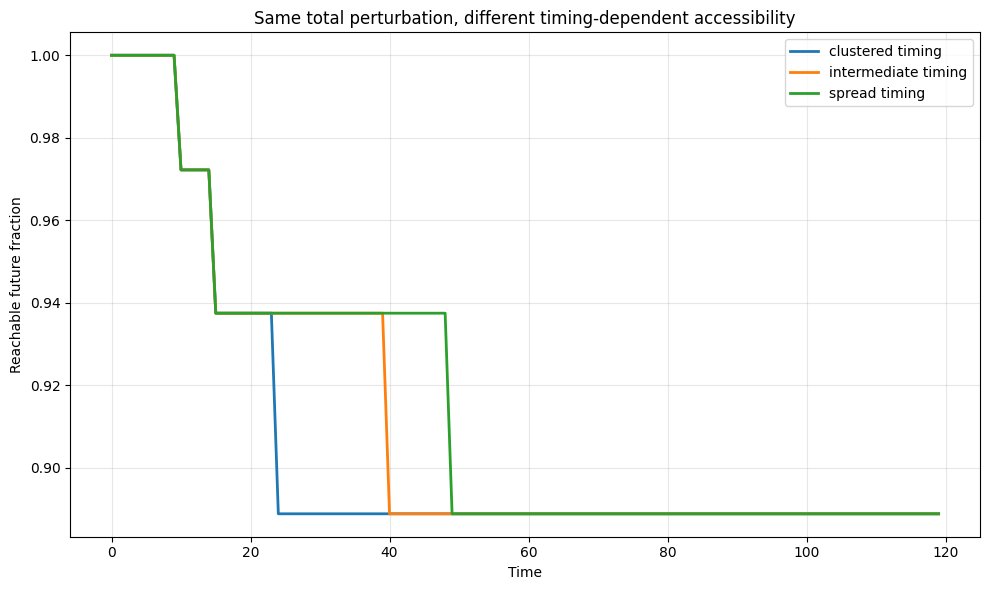

In [51]:
# ============================================================
# Compare reachable futures across timing scenarios
# ============================================================

plt.figure(figsize=(10, 6))

for name, df in scenario_results.items():

    plt.plot(
        df["time"],
        df["accessible_fraction"],
        linewidth=2,
        label=f"{name} timing"
    )

plt.xlabel("Time")
plt.ylabel("Reachable future fraction")
plt.title(
    "Same total perturbation, different timing-dependent accessibility"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "same_total_perturbation_timing_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Recovery kinetics as accessibility constraints

We test whether systems exposed to identical perturbations but different recovery rates display distinct accessibility organization.

Question:

> Can recovery kinetics reshape operational accessibility without altering scaffold?

In [52]:
# ============================================================
# Accessibility cost / coordination inflation
# ============================================================

def weighted_accessibility_metrics(
    G,
    Ge,
    source_node=0
):
    """
    Accessibility cost metrics inside effective graph.
    """

    if source_node not in Ge:

        return {
            "reachable_fraction": 0,
            "mean_path_cost": np.nan,
            "max_path_cost": np.nan,
            "network_efficiency": 0,
        }

    reachable_nodes = nx.node_connected_component(
        Ge,
        source_node
    )

    reachable_fraction = (
        len(reachable_nodes)
        / G.number_of_nodes()
    )

    # Weighted shortest paths
    path_lengths = nx.single_source_shortest_path_length(
        Ge,
        source_node
    )

    lengths = np.array(
        list(path_lengths.values())
    )

    mean_path_cost = np.mean(lengths)
    max_path_cost = np.max(lengths)

    # Efficiency proxy
    efficiency = np.mean(
        1 / (lengths + 1)
    )

    return {
        "reachable_fraction": reachable_fraction,
        "mean_path_cost": mean_path_cost,
        "max_path_cost": max_path_cost,
        "network_efficiency": efficiency,
    }


# ------------------------------------------------------------
# Compare timing scenarios
# ------------------------------------------------------------

cost_records = []

for scenario_name, times in scenarios.items():

    state = initialize_state(N)

    for t in range(120):

        if t in times:
            P = perturbation_strength * perturbation_profile(
                G,
                center_node=center_node,
                radius=3
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=0.20,
            beta=0.03,
            gamma=0.12,
            decay=0.01,
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        Ge = effective_graph(
            G,
            weights,
            threshold=ACCESS_THRESHOLD
        )

        metrics = weighted_accessibility_metrics(
            G,
            Ge,
            source_node=0
        )

        cost_records.append({
            "scenario": scenario_name,
            "time": t,
            **metrics
        })

cost_df = pd.DataFrame(cost_records)

cost_df.to_csv(
    DATA_DIR / "coordination_cost_metrics.csv",
    index=False
)

cost_df.head()

,scenario,time,reachable_fraction,mean_path_cost,max_path_cost,network_efficiency
0,clustered,0,1.0,11.0,22,0.112125
1,clustered,1,1.0,11.0,22,0.112125
2,clustered,2,1.0,11.0,22,0.112125
3,clustered,3,1.0,11.0,22,0.112125
4,clustered,4,1.0,11.0,22,0.112125


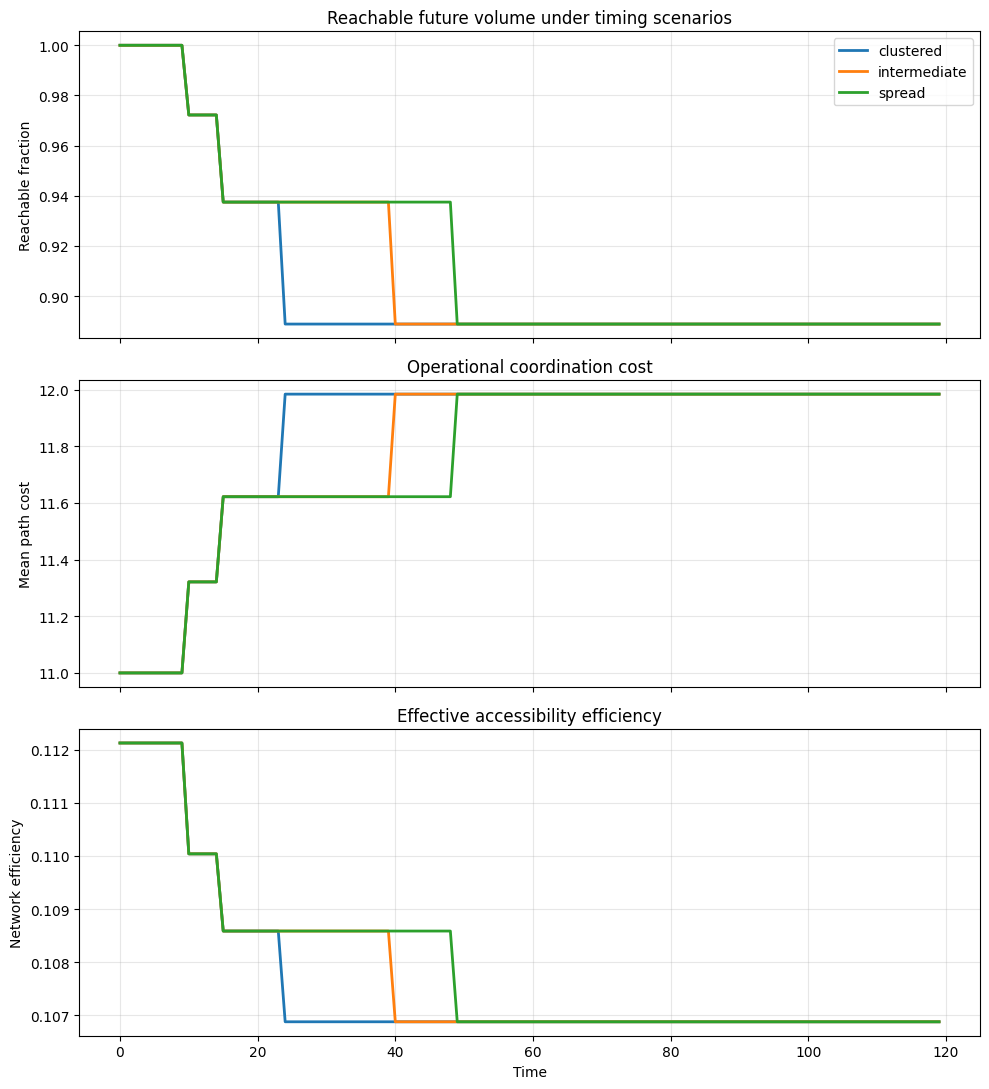

In [53]:
# ============================================================
# Plot coordination cost and efficiency by timing scenario
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 11),
    sharex=True
)

for scenario_name, sub in cost_df.groupby("scenario"):

    axes[0].plot(
        sub["time"],
        sub["reachable_fraction"],
        linewidth=2,
        label=scenario_name
    )

    axes[1].plot(
        sub["time"],
        sub["mean_path_cost"],
        linewidth=2,
        label=scenario_name
    )

    axes[2].plot(
        sub["time"],
        sub["network_efficiency"],
        linewidth=2,
        label=scenario_name
    )

axes[0].set_ylabel("Reachable fraction")
axes[0].set_title("Reachable future volume under timing scenarios")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_ylabel("Mean path cost")
axes[1].set_title("Operational coordination cost")
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel("Network efficiency")
axes[2].set_xlabel("Time")
axes[2].set_title("Effective accessibility efficiency")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "coordination_cost_and_efficiency_timing_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Robustness analysis

To evaluate whether the observed organization is robust rather than parameter-specific, we test:

- threshold robustness,
- stochastic robustness,
- falsification-oriented controls.

In [54]:
# ============================================================
# Regularized weighted accessibility cost
# Avoids numerical cost explosion when traversability is near zero
# ============================================================

def weighted_effective_graph(G, weights, epsilon=0.05):
    """
    Keep the full scaffold, but assign traversal cost from dynamic traversability.

    High traversability -> low cost
    Low traversability  -> high cost

    epsilon regularizes near-zero traversability.
    """
    Gw = nx.Graph()
    Gw.add_nodes_from(G.nodes())

    for (u, v), w in weights.items():

        cost = 1.0 / (w + epsilon)

        Gw.add_edge(
            u,
            v,
            traversability=w,
            cost=cost
        )

    return Gw


def weighted_cost_metrics(G, Gw, source_node=0):
    """
    Compute weighted accessibility metrics from source node.
    """

    path_costs = nx.single_source_dijkstra_path_length(
        Gw,
        source_node,
        weight="cost"
    )

    costs = np.array(list(path_costs.values()))

    return {
        "weighted_mean_path_cost": np.mean(costs),
        "weighted_max_path_cost": np.max(costs),
        "weighted_efficiency": np.mean(1 / (costs + 1)),
    }


weighted_records = []

for scenario_name, times in scenarios.items():

    state = initialize_state(N)

    for t in range(120):

        if t in times:
            P = perturbation_strength * perturbation_profile(
                G,
                center_node=center_node,
                radius=3
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=0.20,
            beta=0.03,
            gamma=0.12,
            decay=0.01,
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        Gw = weighted_effective_graph(
            G,
            weights,
            epsilon=0.05
        )

        metrics = weighted_cost_metrics(
            G,
            Gw,
            source_node=0
        )

        weighted_records.append({
            "scenario": scenario_name,
            "time": t,
            **metrics,
            "mean_r": np.mean(state["r"]),
            "mean_D": np.mean(state["D"]),
            "min_r": np.min(state["r"]),
            "max_D": np.max(state["D"]),
        })

weighted_cost_df = pd.DataFrame(weighted_records)

weighted_cost_df.to_csv(
    DATA_DIR / "regularized_weighted_accessibility_cost_metrics.csv",
    index=False
)

weighted_cost_df.head()

,scenario,time,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,mean_D,min_r,max_D
0,clustered,0,10.47619,20.952381,0.11653,1.0,0.0,1.0,0.0
1,clustered,1,10.47619,20.952381,0.11653,1.0,0.0,1.0,0.0
2,clustered,2,10.47619,20.952381,0.11653,1.0,0.0,1.0,0.0
3,clustered,3,10.47619,20.952381,0.11653,1.0,0.0,1.0,0.0
4,clustered,4,10.47619,20.952381,0.11653,1.0,0.0,1.0,0.0


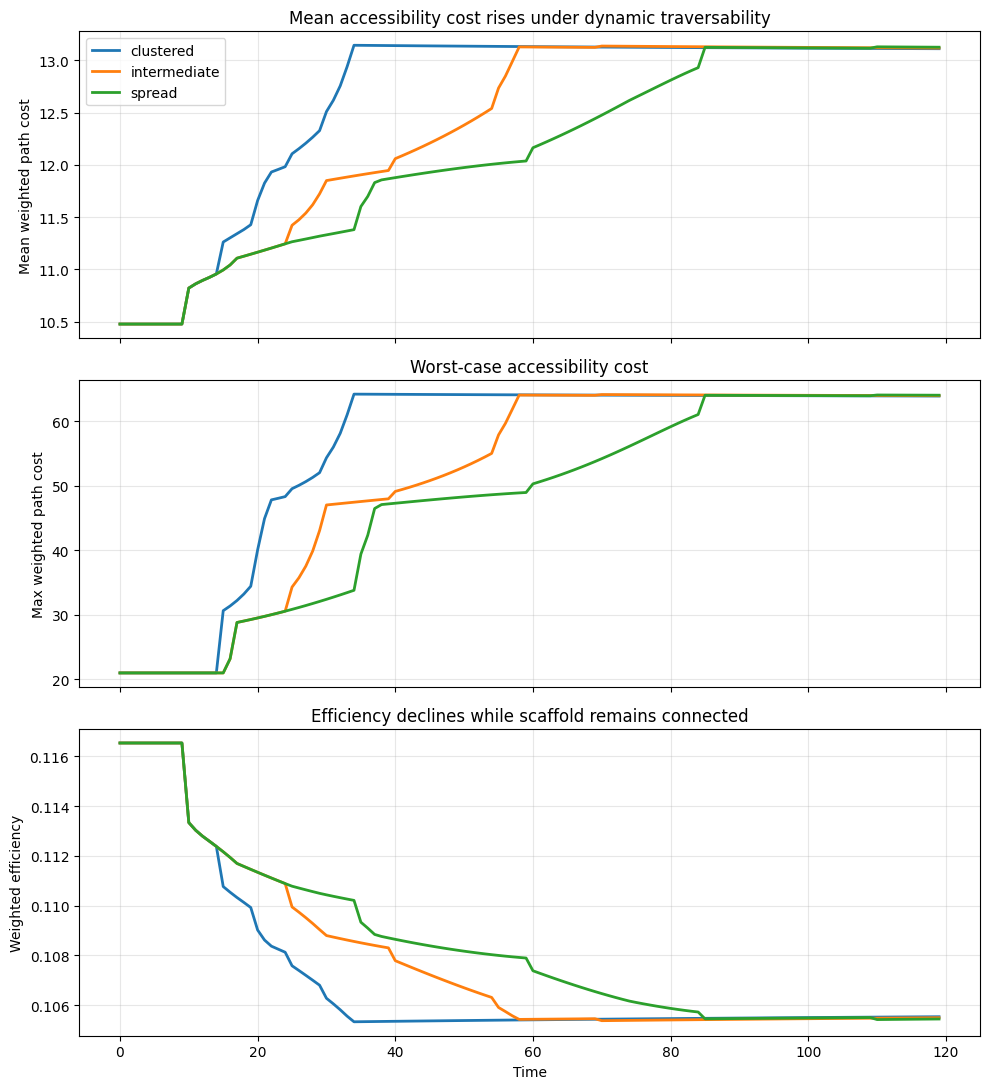

In [55]:
# ============================================================
# Plot weighted accessibility cost under timing scenarios
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 11),
    sharex=True
)

for scenario_name, sub in weighted_cost_df.groupby("scenario"):

    axes[0].plot(
        sub["time"],
        sub["weighted_mean_path_cost"],
        linewidth=2,
        label=scenario_name
    )

    axes[1].plot(
        sub["time"],
        sub["weighted_max_path_cost"],
        linewidth=2,
        label=scenario_name
    )

    axes[2].plot(
        sub["time"],
        sub["weighted_efficiency"],
        linewidth=2,
        label=scenario_name
    )

axes[0].set_ylabel("Mean weighted path cost")
axes[0].set_title("Mean accessibility cost rises under dynamic traversability")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_ylabel("Max weighted path cost")
axes[1].set_title("Worst-case accessibility cost")
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel("Weighted efficiency")
axes[2].set_xlabel("Time")
axes[2].set_title("Efficiency declines while scaffold remains connected")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "weighted_accessibility_cost_timing_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Falsification-oriented controls

The goal is not only to observe organization but attempt to weaken or remove it.

Controls include:

1. fixed recovery kinetics,
2. reduced perturbation-history persistence,
3. stochastic perturbation variability.

In [56]:
# ============================================================
# Same perturbation timing, different recovery kinetics
# Dynamic accessibility under recovery-rate constraints
# ============================================================

recovery_cases = {
    "fast recovery": {
        "beta": 0.05,
        "gamma": 0.08,
        "decay": 0.02,
    },
    "baseline recovery": {
        "beta": 0.03,
        "gamma": 0.12,
        "decay": 0.01,
    },
    "slow recovery": {
        "beta": 0.015,
        "gamma": 0.16,
        "decay": 0.005,
    },
}

# Same perturbation schedule for all cases
fixed_schedule = [10, 15, 20, 25, 30]

recovery_records = []

for case_name, params in recovery_cases.items():

    state = initialize_state(N)

    for t in range(120):

        if t in fixed_schedule:
            P = perturbation_strength * perturbation_profile(
                G,
                center_node=center_node,
                radius=3
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=0.20,
            beta=params["beta"],
            gamma=params["gamma"],
            decay=params["decay"],
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        # Binary effective graph
        Ge = effective_graph(
            G,
            weights,
            threshold=ACCESS_THRESHOLD
        )

        binary_metrics = accessibility_metrics(
            G,
            Ge,
            source=source_node
        )

        # Weighted full graph
        Gw = weighted_effective_graph(
            G,
            weights,
            epsilon=0.05
        )

        weighted_metrics = weighted_cost_metrics(
            G,
            Gw,
            source_node=source_node
        )

        recovery_records.append({
            "case": case_name,
            "time": t,
            **binary_metrics,
            **weighted_metrics,
            "mean_r": np.mean(state["r"]),
            "min_r": np.min(state["r"]),
            "mean_D": np.mean(state["D"]),
            "max_D": np.max(state["D"]),
        })

recovery_df = pd.DataFrame(recovery_records)

recovery_df.to_csv(
    DATA_DIR / "same_timing_different_recovery_kinetics.csv",
    index=False
)

recovery_df.head()

,case,time,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D
0,fast recovery,0,144,144,1.0,264,264,1.0,10.47619,20.952381,0.11653,1.0,1.0,0.0,0.0
1,fast recovery,1,144,144,1.0,264,264,1.0,10.47619,20.952381,0.11653,1.0,1.0,0.0,0.0
2,fast recovery,2,144,144,1.0,264,264,1.0,10.47619,20.952381,0.11653,1.0,1.0,0.0,0.0
3,fast recovery,3,144,144,1.0,264,264,1.0,10.47619,20.952381,0.11653,1.0,1.0,0.0,0.0
4,fast recovery,4,144,144,1.0,264,264,1.0,10.47619,20.952381,0.11653,1.0,1.0,0.0,0.0


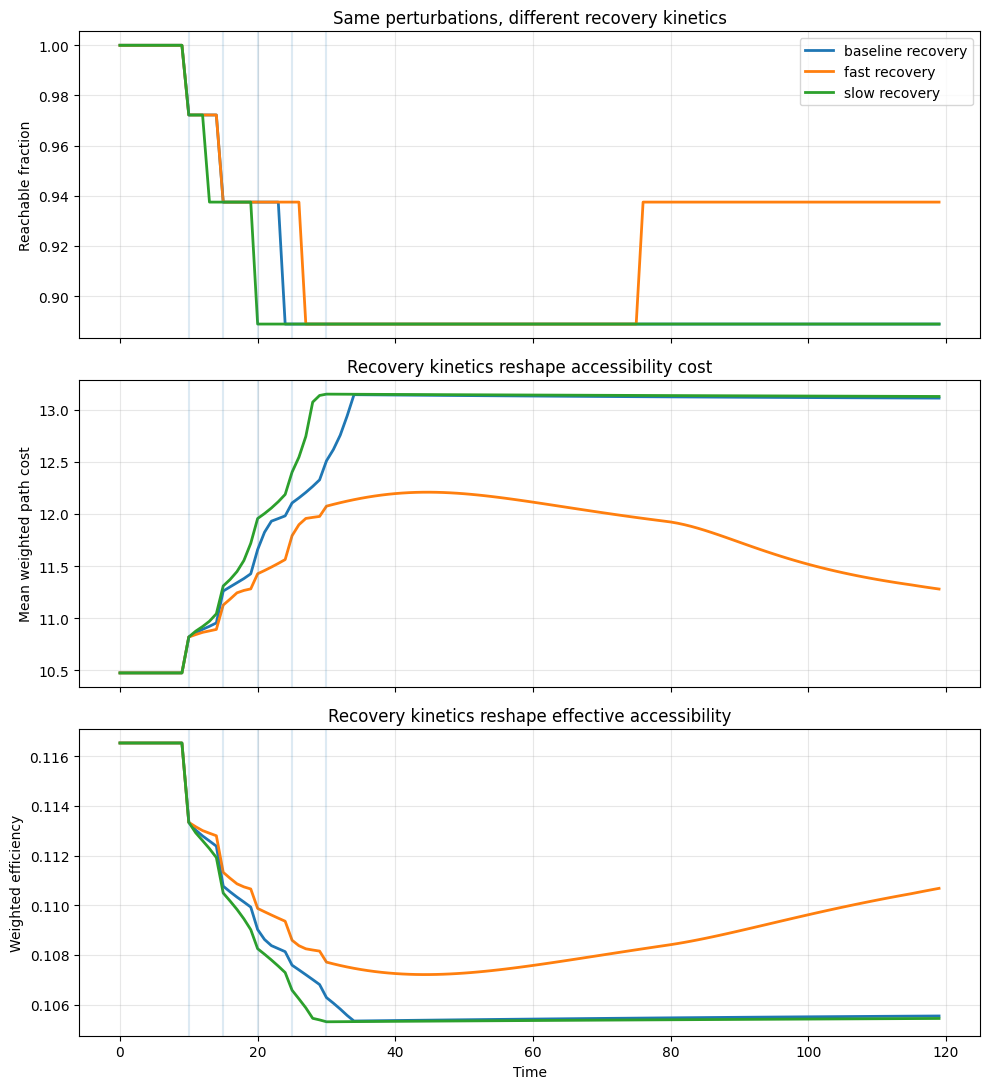

In [57]:
# ============================================================
# Plot recovery kinetics effects on dynamic accessibility
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 11),
    sharex=True
)

for case_name, sub in recovery_df.groupby("case"):

    axes[0].plot(
        sub["time"],
        sub["accessible_fraction"],
        linewidth=2,
        label=case_name
    )

    axes[1].plot(
        sub["time"],
        sub["weighted_mean_path_cost"],
        linewidth=2,
        label=case_name
    )

    axes[2].plot(
        sub["time"],
        sub["weighted_efficiency"],
        linewidth=2,
        label=case_name
    )

for ax in axes:
    for pt in fixed_schedule:
        ax.axvline(pt, alpha=0.15)

axes[0].set_ylabel("Reachable fraction")
axes[0].set_title("Same perturbations, different recovery kinetics")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_ylabel("Mean weighted path cost")
axes[1].set_title("Recovery kinetics reshape accessibility cost")
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel("Weighted efficiency")
axes[2].set_xlabel("Time")
axes[2].set_title("Recovery kinetics reshape effective accessibility")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "same_timing_different_recovery_kinetics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# ============================================================
# Stress–Recovery Phase Map
# Perturbation density vs recovery kinetics
# ============================================================

def generate_schedule(start, interval, n_events=5):
    return [start + i * interval for i in range(n_events)]


def run_phase_map_case(
    interval,
    beta,
    gamma,
    decay,
    perturbation_strength=3.0,
    T=140,
    alpha=0.20,
    access_threshold=0.65,
    source_node=0,
):
    """
    Run one phase-map condition:
    - interval controls perturbation density
    - beta/gamma/decay control recovery kinetics
    """

    schedule = generate_schedule(
        start=10,
        interval=interval,
        n_events=5
    )

    state = initialize_state(N)

    final_metrics = None

    for t in range(T):

        if t in schedule:
            P = perturbation_strength * perturbation_profile(
                G,
                center_node=center_node,
                radius=3
            )
        else:
            P = np.zeros(N)

        state = update_state(
            state,
            P,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            decay=decay,
            dt=1.0
        )

        weights = edge_traversability(
            G,
            state["r"],
            state["D"]
        )

        Ge = effective_graph(
            G,
            weights,
            threshold=access_threshold
        )

        binary_metrics = accessibility_metrics(
            G,
            Ge,
            source=source_node
        )

        Gw = weighted_effective_graph(
            G,
            weights,
            epsilon=0.05
        )

        weighted_metrics = weighted_cost_metrics(
            G,
            Gw,
            source_node=source_node
        )

        final_metrics = {
            **binary_metrics,
            **weighted_metrics,
            "mean_r": np.mean(state["r"]),
            "min_r": np.min(state["r"]),
            "mean_D": np.mean(state["D"]),
            "max_D": np.max(state["D"]),
        }

    return final_metrics


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

interval_axis = np.array([4, 6, 8, 10, 12, 16, 20, 25, 30])
recovery_axis = np.linspace(0.012, 0.060, 9)

phase_records = []

for interval in interval_axis:

    for beta in recovery_axis:

        # Couple recovery and damage parameters conservatively
        # slower beta -> stronger effective burden persistence
        gamma_case = 0.18 - beta
        decay_case = beta / 3

        metrics = run_phase_map_case(
            interval=interval,
            beta=beta,
            gamma=gamma_case,
            decay=decay_case,
            perturbation_strength=3.0,
            T=140,
            alpha=0.20,
            access_threshold=0.65,
            source_node=0
        )

        phase_records.append({
            "interval": interval,
            "perturbation_density": 1 / interval,
            "recovery_beta": beta,
            "gamma": gamma_case,
            "decay": decay_case,
            **metrics
        })

phase_map_df = pd.DataFrame(phase_records)

phase_map_df.to_csv(
    DATA_DIR / "stress_recovery_phase_map.csv",
    index=False
)

phase_map_df.head()

,interval,perturbation_density,recovery_beta,gamma,decay,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D
0,4,0.25,0.012,0.168,0.004,144,128,0.888889,228,264,0.863636,13.126988,64.095274,0.105437,0.888889,0.0,0.200725,9.238104
1,4,0.25,0.018,0.162,0.006,144,128,0.888889,228,264,0.863636,13.118211,64.016278,0.105491,0.888889,0.0,0.157440,7.245951
2,4,0.25,0.024,0.156,0.008,144,128,0.888889,228,264,0.863636,13.111262,63.953743,0.105536,0.888889,0.0,0.123444,5.681353
3,4,0.25,0.030,0.150,0.010,144,128,0.888889,228,264,0.863636,13.105773,63.904340,0.105571,0.888889,0.0,0.096754,4.452987
4,4,0.25,0.036,0.144,0.012,144,128,0.888889,228,264,0.863636,12.437763,54.022675,0.106624,0.894881,0.0,0.075808,3.488942


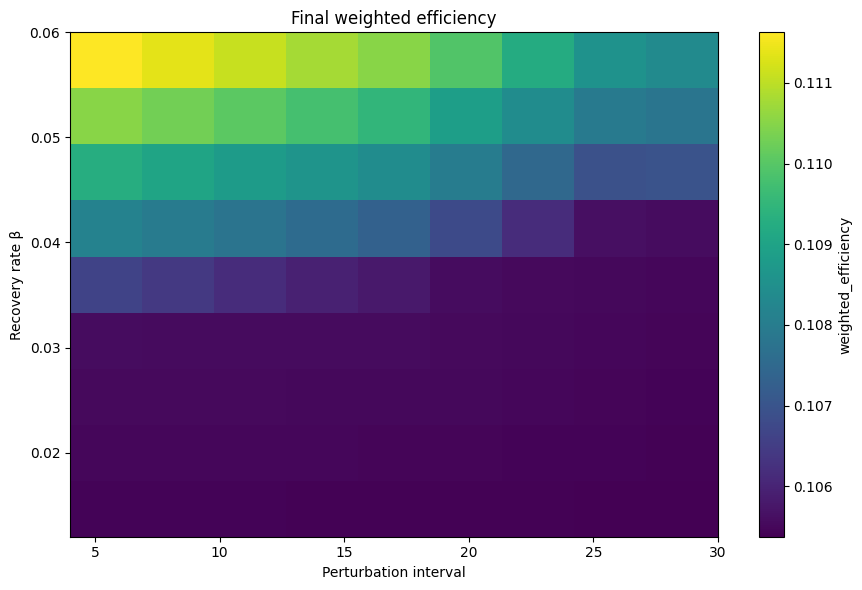

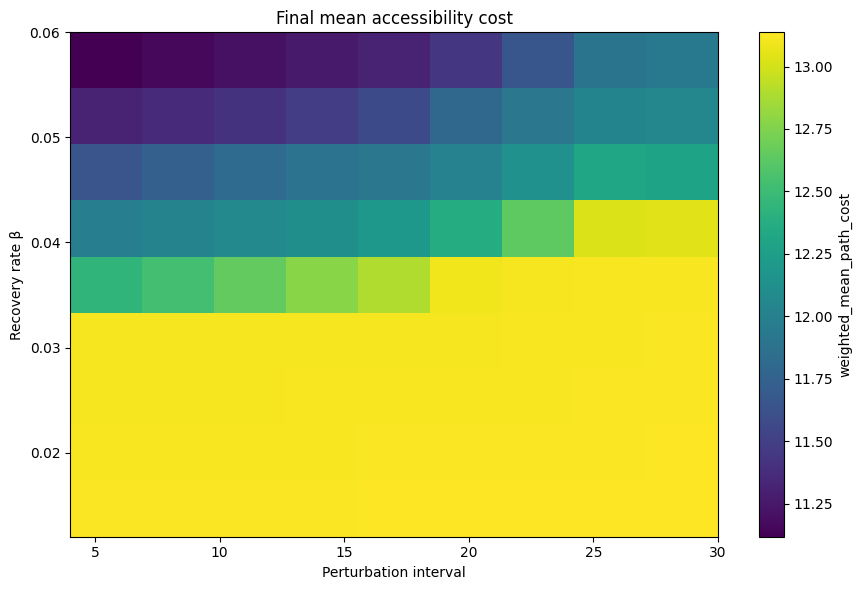

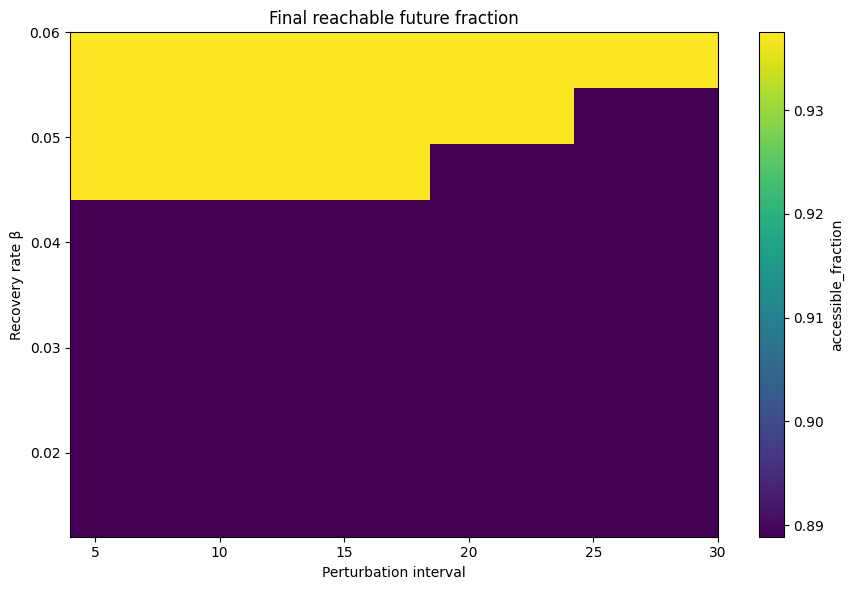

In [59]:
# ============================================================
# Plot Stress–Recovery Phase Maps
# ============================================================

def pivot_metric(df, metric):
    return df.pivot(
        index="recovery_beta",
        columns="interval",
        values=metric
    )


metrics_to_plot = {
    "weighted_efficiency": "Final weighted efficiency",
    "weighted_mean_path_cost": "Final mean accessibility cost",
    "accessible_fraction": "Final reachable future fraction",
}

for metric, title in metrics_to_plot.items():

    pivot = pivot_metric(
        phase_map_df,
        metric
    )

    plt.figure(figsize=(9, 6))

    plt.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        extent=[
            interval_axis.min(),
            interval_axis.max(),
            recovery_axis.min(),
            recovery_axis.max()
        ]
    )

    plt.colorbar(label=metric)

    plt.xlabel("Perturbation interval")
    plt.ylabel("Recovery rate β")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"stress_recovery_phase_map_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [60]:
# ============================================================
# Threshold robustness for stress–recovery phase map
# ============================================================

threshold_values = [0.55, 0.65, 0.75]

threshold_records = []

for threshold in threshold_values:

    for interval in interval_axis:

        for beta in recovery_axis:

            gamma_case = 0.18 - beta
            decay_case = beta / 3

            metrics = run_phase_map_case(
                interval=interval,
                beta=beta,
                gamma=gamma_case,
                decay=decay_case,
                perturbation_strength=3.0,
                T=140,
                alpha=0.20,
                access_threshold=threshold,
                source_node=0
            )

            threshold_records.append({
                "threshold": threshold,
                "interval": interval,
                "perturbation_density": 1 / interval,
                "recovery_beta": beta,
                "gamma": gamma_case,
                "decay": decay_case,
                **metrics
            })

threshold_df = pd.DataFrame(threshold_records)

threshold_df.to_csv(
    DATA_DIR / "threshold_robustness_phase_map.csv",
    index=False
)

threshold_df.head()

,threshold,interval,perturbation_density,recovery_beta,gamma,decay,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D
0,0.55,4,0.25,0.012,0.168,0.004,144,128,0.888889,228,264,0.863636,13.126988,64.095274,0.105437,0.888889,0.0,0.200725,9.238104
1,0.55,4,0.25,0.018,0.162,0.006,144,128,0.888889,228,264,0.863636,13.118211,64.016278,0.105491,0.888889,0.0,0.157440,7.245951
2,0.55,4,0.25,0.024,0.156,0.008,144,128,0.888889,228,264,0.863636,13.111262,63.953743,0.105536,0.888889,0.0,0.123444,5.681353
3,0.55,4,0.25,0.030,0.150,0.010,144,128,0.888889,228,264,0.863636,13.105773,63.904340,0.105571,0.888889,0.0,0.096754,4.452987
4,0.55,4,0.25,0.036,0.144,0.012,144,128,0.888889,228,264,0.863636,12.437763,54.022675,0.106624,0.894881,0.0,0.075808,3.488942


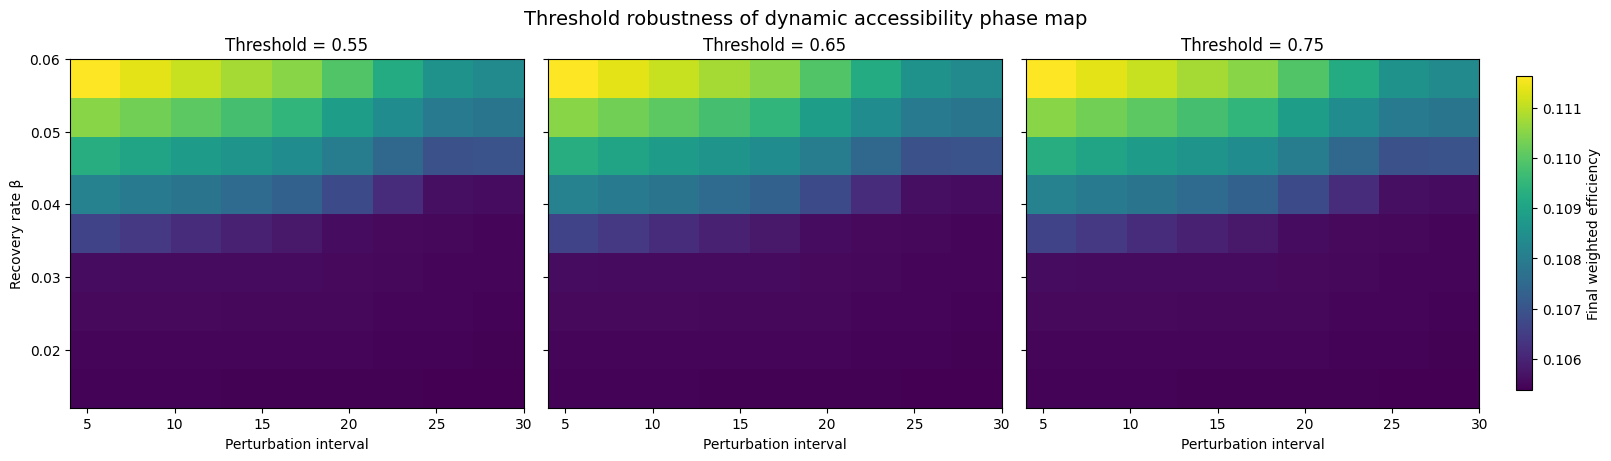

In [61]:
# ============================================================
# Plot threshold robustness maps (clean version)
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4.5),
    sharey=True,
    constrained_layout=True
)

for ax, threshold in zip(axes, threshold_values):

    sub = threshold_df[
        threshold_df["threshold"] == threshold
    ]

    pivot = sub.pivot(
        index="recovery_beta",
        columns="interval",
        values="weighted_efficiency"
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        extent=[
            interval_axis.min(),
            interval_axis.max(),
            recovery_axis.min(),
            recovery_axis.max()
        ]
    )

    ax.set_title(f"Threshold = {threshold}")
    ax.set_xlabel("Perturbation interval")

axes[0].set_ylabel("Recovery rate β")

fig.suptitle(
    "Threshold robustness of dynamic accessibility phase map",
    fontsize=14
)

# dedicated colorbar axis outside
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.9,
    pad=0.02
)

cbar.set_label(
    "Final weighted efficiency"
)

plt.savefig(
    FIG_DIR / "threshold_robustness_weighted_efficiency_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
# ============================================================
# NULL CONTROL 1
# Homogeneous recovery kinetics
# (remove recovery heterogeneity)
# ============================================================

null_records = []

for interval in interval_axis:

    for beta in recovery_axis:

        # deliberately collapse recovery variability
        gamma_case = 0.12
        decay_case = 0.04

        metrics = run_phase_map_case(
            interval=interval,
            beta=0.04,   # fixed recovery
            gamma=gamma_case,
            decay=decay_case,
            perturbation_strength=3.0,
            T=140,
            alpha=0.20,
            access_threshold=0.65,
            source_node=0
        )

        null_records.append({
            "interval": interval,
            "recovery_beta_axis": beta,
            **metrics
        })

null_df = pd.DataFrame(null_records)

null_df.to_csv(
    DATA_DIR / "null_control_fixed_recovery.csv",
    index=False
)

null_df.head()

,interval,recovery_beta_axis,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D
0,4,0.012,144,143,0.993056,261,264,0.988636,10.662652,20.952381,0.114639,0.976595,0.295726,0.002396,0.110261
1,4,0.018,144,143,0.993056,261,264,0.988636,10.662652,20.952381,0.114639,0.976595,0.295726,0.002396,0.110261
2,4,0.024,144,143,0.993056,261,264,0.988636,10.662652,20.952381,0.114639,0.976595,0.295726,0.002396,0.110261
3,4,0.030,144,143,0.993056,261,264,0.988636,10.662652,20.952381,0.114639,0.976595,0.295726,0.002396,0.110261
4,4,0.036,144,143,0.993056,261,264,0.988636,10.662652,20.952381,0.114639,0.976595,0.295726,0.002396,0.110261


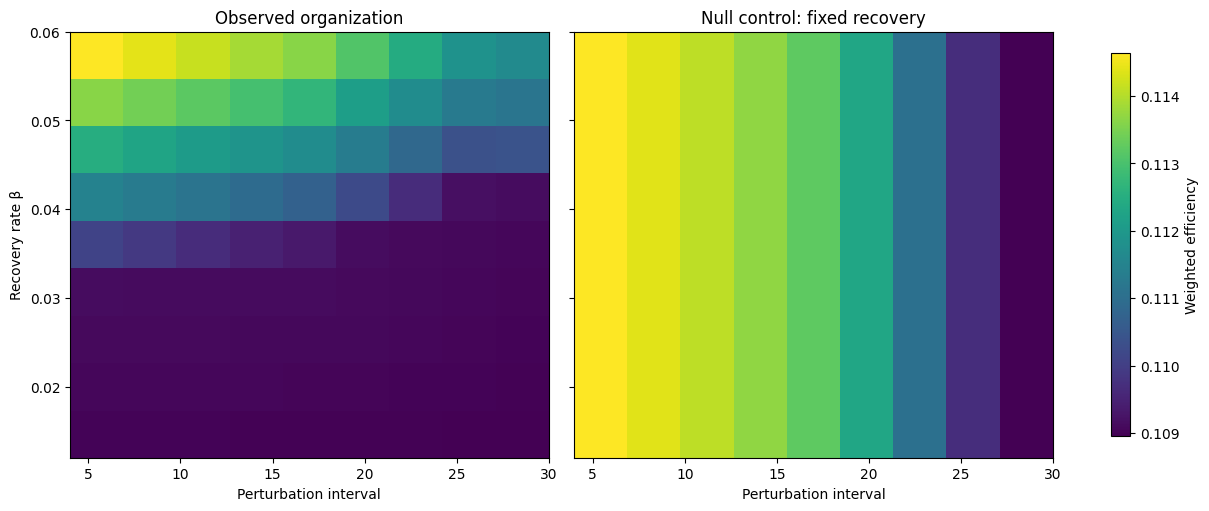

In [63]:
# ============================================================
# Compare real map vs null control
# ============================================================

real_pivot = phase_map_df.pivot(
    index="recovery_beta",
    columns="interval",
    values="weighted_efficiency"
)

null_pivot = null_df.pivot(
    index="recovery_beta_axis",
    columns="interval",
    values="weighted_efficiency"
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True,
    constrained_layout=True
)

# -------------------------
# REAL
# -------------------------
im1 = axes[0].imshow(
    real_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[0].set_title(
    "Observed organization"
)

axes[0].set_xlabel(
    "Perturbation interval"
)

axes[0].set_ylabel(
    "Recovery rate β"
)

# -------------------------
# NULL
# -------------------------
im2 = axes[1].imshow(
    null_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[1].set_title(
    "Null control: fixed recovery"
)

axes[1].set_xlabel(
    "Perturbation interval"
)

cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.90
)

cbar.set_label(
    "Weighted efficiency"
)

plt.savefig(
    FIG_DIR / "null_control_fixed_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
# ============================================================
# NULL CONTROL 2
# Remove damage memory / history persistence
# ============================================================

no_memory_records = []

for interval in interval_axis:

    for beta in recovery_axis:

        # Remove persistent damage memory
        gamma_case = 0.01
        decay_case = 0.20

        metrics = run_phase_map_case(
            interval=interval,
            beta=beta,
            gamma=gamma_case,
            decay=decay_case,
            perturbation_strength=3.0,
            T=140,
            alpha=0.20,
            access_threshold=0.65,
            source_node=0
        )

        no_memory_records.append({
            "interval": interval,
            "recovery_beta": beta,
            "gamma": gamma_case,
            "decay": decay_case,
            **metrics
        })

no_memory_df = pd.DataFrame(no_memory_records)

no_memory_df.to_csv(
    DATA_DIR / "null_control_no_damage_memory.csv",
    index=False
)

no_memory_df.head()

,interval,recovery_beta,gamma,decay,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D
0,4,0.012,0.01,0.2,144,144,1.0,264,264,1.0,10.562090,20.952381,0.115570,0.985873,0.706295,1.222154e-12,5.624802e-11
1,4,0.018,0.01,0.2,144,144,1.0,264,264,1.0,10.514822,20.952381,0.116077,0.992950,0.846666,1.222154e-12,5.624802e-11
2,4,0.024,0.01,0.2,144,144,1.0,264,264,1.0,10.494432,20.952381,0.116312,0.996507,0.920925,1.222154e-12,5.624802e-11
3,4,0.030,0.01,0.2,144,144,1.0,264,264,1.0,10.484984,20.952381,0.116424,0.998277,0.959629,1.222154e-12,5.624802e-11
4,4,0.036,0.01,0.2,144,144,1.0,264,264,1.0,10.480437,20.952381,0.116478,0.999158,0.979569,1.222154e-12,5.624802e-11


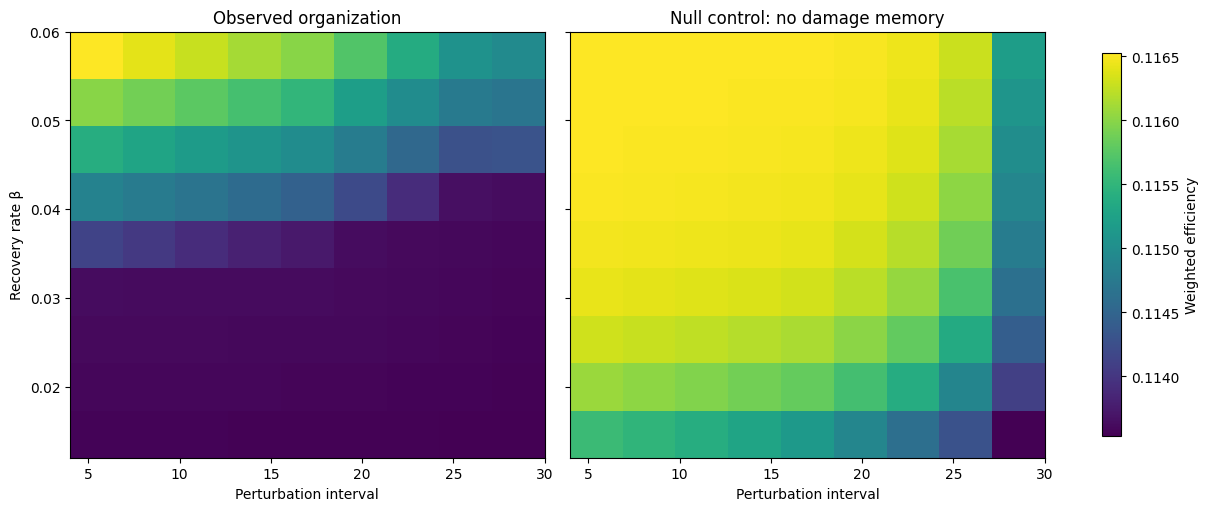

In [65]:
# ============================================================
# Compare observed map vs no-memory null control
# ============================================================

real_pivot = phase_map_df.pivot(
    index="recovery_beta",
    columns="interval",
    values="weighted_efficiency"
)

no_memory_pivot = no_memory_df.pivot(
    index="recovery_beta",
    columns="interval",
    values="weighted_efficiency"
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True,
    constrained_layout=True
)

# -------------------------
# Observed
# -------------------------
im1 = axes[0].imshow(
    real_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[0].set_title("Observed organization")
axes[0].set_xlabel("Perturbation interval")
axes[0].set_ylabel("Recovery rate β")

# -------------------------
# No-memory control
# -------------------------
im2 = axes[1].imshow(
    no_memory_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[1].set_title("Null control: no damage memory")
axes[1].set_xlabel("Perturbation interval")

cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.90
)

cbar.set_label("Weighted efficiency")

plt.savefig(
    FIG_DIR / "null_control_no_damage_memory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# ============================================================
# STOCHASTIC ROBUSTNESS
# Noise in perturbation and recovery kinetics
# ============================================================

np.random.seed(42)

noise_records = []

for interval in interval_axis:

    for beta in recovery_axis:

        gamma_case = 0.18 - beta
        decay_case = beta / 3

        state = initialize_state(N)

        schedule = generate_schedule(
            start=10,
            interval=interval,
            n_events=5
        )

        final_metrics = None

        for t in range(140):

            # ---------------------------------
            # perturbation noise
            # ---------------------------------
            perturbation_scale = np.clip(
                np.random.normal(1.0, 0.10),
                0.75,
                1.25
            )

            # ---------------------------------
            # recovery noise
            # ---------------------------------
            beta_t = beta * np.clip(
                np.random.normal(1.0, 0.05),
                0.85,
                1.15
            )

            gamma_t = gamma_case * np.clip(
                np.random.normal(1.0, 0.05),
                0.85,
                1.15
            )

            decay_t = decay_case * np.clip(
                np.random.normal(1.0, 0.05),
                0.85,
                1.15
            )

            if t in schedule:

                P = (
                    perturbation_scale *
                    3.0 *
                    perturbation_profile(
                        G,
                        center_node=center_node,
                        radius=3
                    )
                )

            else:
                P = np.zeros(N)

            state = update_state(
                state,
                P,
                alpha=0.20,
                beta=beta_t,
                gamma=gamma_t,
                decay=decay_t,
                dt=1.0
            )

            weights = edge_traversability(
                G,
                state["r"],
                state["D"]
            )

            Ge = effective_graph(
                G,
                weights,
                threshold=0.65
            )

            binary_metrics = accessibility_metrics(
                G,
                Ge,
                source=0
            )

            Gw = weighted_effective_graph(
                G,
                weights,
                epsilon=0.05
            )

            weighted_metrics = weighted_cost_metrics(
                G,
                Gw,
                source_node=0
            )

            final_metrics = {
                **binary_metrics,
                **weighted_metrics
            }

        noise_records.append({
            "interval": interval,
            "recovery_beta": beta,
            **final_metrics
        })

noise_df = pd.DataFrame(noise_records)

noise_df.to_csv(
    DATA_DIR / "noise_robustness_phase_map.csv",
    index=False
)

noise_df.head()

,interval,recovery_beta,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency
0,4,0.012,144,128,0.888889,228,264,0.863636,13.126318,64.089244,0.105441
1,4,0.018,144,128,0.888889,228,264,0.863636,13.117827,64.012823,0.105494
2,4,0.024,144,128,0.888889,228,264,0.863636,13.108080,63.925104,0.105556
3,4,0.030,144,128,0.888889,228,264,0.863636,13.105392,63.900909,0.105573
4,4,0.036,144,128,0.888889,228,264,0.863636,12.381229,53.278458,0.106767


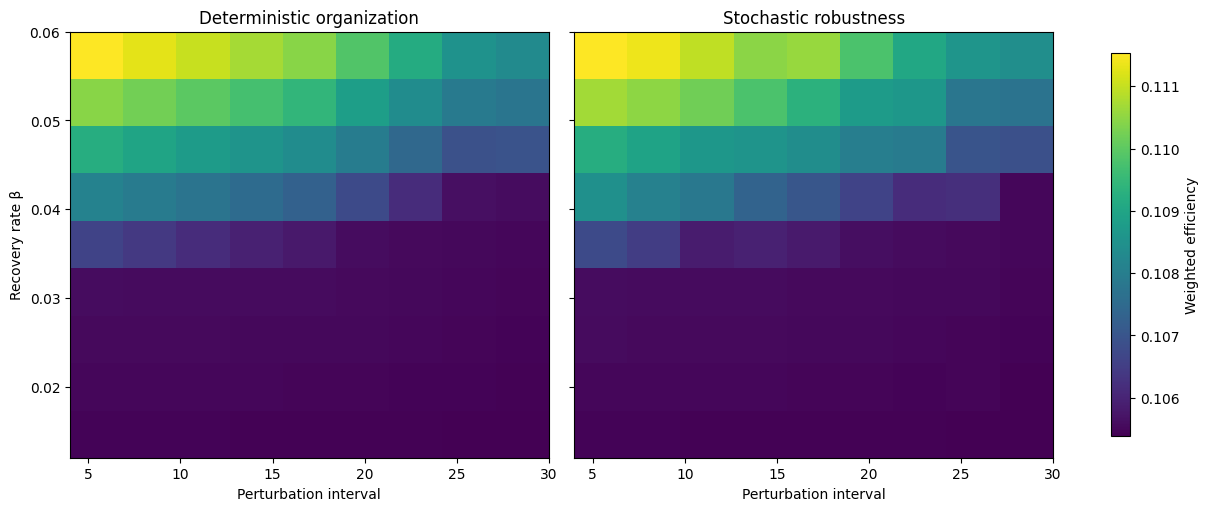

In [67]:
# ============================================================
# Compare deterministic vs noisy organization
# ============================================================

real_pivot = phase_map_df.pivot(
    index="recovery_beta",
    columns="interval",
    values="weighted_efficiency"
)

noise_pivot = noise_df.pivot(
    index="recovery_beta",
    columns="interval",
    values="weighted_efficiency"
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=True,
    constrained_layout=True
)

# --------------------------
# deterministic
# --------------------------
im1 = axes[0].imshow(
    real_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[0].set_title(
    "Deterministic organization"
)

axes[0].set_xlabel(
    "Perturbation interval"
)

axes[0].set_ylabel(
    "Recovery rate β"
)

# --------------------------
# noisy
# --------------------------
im2 = axes[1].imshow(
    noise_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ]
)

axes[1].set_title(
    "Stochastic robustness"
)

axes[1].set_xlabel(
    "Perturbation interval"
)

cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.90
)

cbar.set_label(
    "Weighted efficiency"
)

plt.savefig(
    FIG_DIR / "noise_robustness_phase_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Operational regime organization

The previous robustness and falsification analyses motivate asking whether accessibility organization can be summarized into interpretable operational accessibility regimes.

To summarize the emergent accessibility geometry, we classify regions heuristically into operational accessibility regimes.

Important:

> these regimes are visualization-oriented operational categories rather than hard physical boundaries.

The goal is descriptive rather than predictive:

> to visualize how perturbation timing and recovery kinetics jointly reorganize effective accessibility.

In [68]:
# ============================================================
# Operational regime classification from weighted efficiency
# ============================================================

regime_df = phase_map_df.copy()

eff = regime_df["weighted_efficiency"]

# Percentile-based thresholds from observed map
q25 = eff.quantile(0.25)
q50 = eff.quantile(0.50)
q75 = eff.quantile(0.75)

def classify_accessibility_regime(x):

    if x >= q75:
        return "healthy"

    elif x >= q50:
        return "strained"

    elif x >= q25:
        return "fragile"

    else:
        return "trapped"


regime_df["regime"] = regime_df[
    "weighted_efficiency"
].apply(classify_accessibility_regime)

regime_df.to_csv(
    DATA_DIR / "dynamic_accessibility_regime_classification.csv",
    index=False
)

print("Efficiency thresholds:")
print("q75 healthy boundary:", q75)
print("q50 strained boundary:", q50)
print("q25 fragile boundary:", q25)

regime_df.head()

Efficiency thresholds:
q75 healthy boundary: 0.10835662678876694
q50 strained boundary: 0.10557369524003375
q25 fragile boundary: 0.10548626645448174


,interval,perturbation_density,recovery_beta,gamma,decay,structural_reachable,effective_reachable,accessible_fraction,effective_edges,structural_edges,edge_fraction,weighted_mean_path_cost,weighted_max_path_cost,weighted_efficiency,mean_r,min_r,mean_D,max_D,regime
0,4,0.25,0.012,0.168,0.004,144,128,0.888889,228,264,0.863636,13.126988,64.095274,0.105437,0.888889,0.0,0.200725,9.238104,trapped
1,4,0.25,0.018,0.162,0.006,144,128,0.888889,228,264,0.863636,13.118211,64.016278,0.105491,0.888889,0.0,0.157440,7.245951,fragile
2,4,0.25,0.024,0.156,0.008,144,128,0.888889,228,264,0.863636,13.111262,63.953743,0.105536,0.888889,0.0,0.123444,5.681353,fragile
3,4,0.25,0.030,0.150,0.010,144,128,0.888889,228,264,0.863636,13.105773,63.904340,0.105571,0.888889,0.0,0.096754,4.452987,fragile
4,4,0.25,0.036,0.144,0.012,144,128,0.888889,228,264,0.863636,12.437763,54.022675,0.106624,0.894881,0.0,0.075808,3.488942,strained


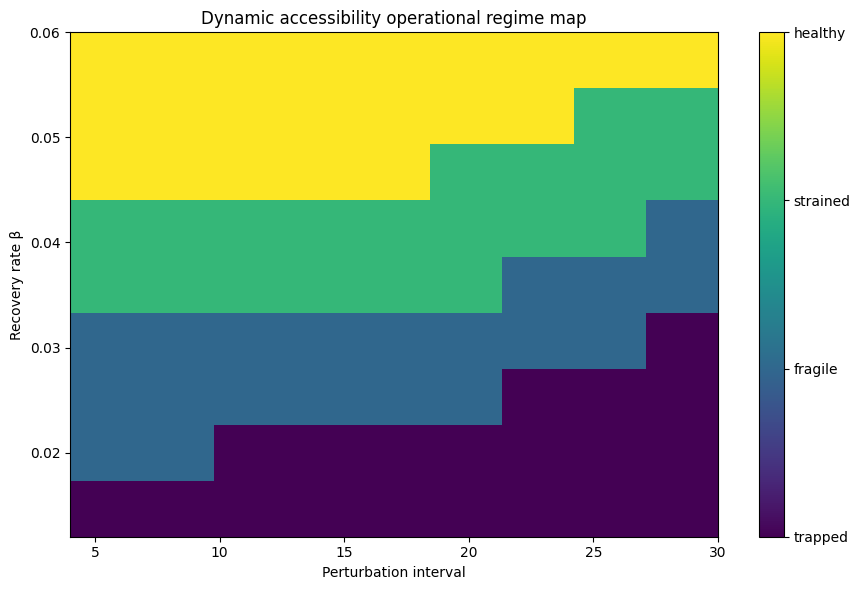

In [69]:
# ============================================================
# Plot operational phase diagram
# ============================================================

regime_order = {
    "trapped": 0,
    "fragile": 1,
    "strained": 2,
    "healthy": 3,
}

regime_numeric = regime_df.copy()
regime_numeric["regime_id"] = regime_numeric[
    "regime"
].map(regime_order)

regime_pivot = regime_numeric.pivot(
    index="recovery_beta",
    columns="interval",
    values="regime_id"
)

plt.figure(figsize=(9, 6))

im = plt.imshow(
    regime_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        interval_axis.min(),
        interval_axis.max(),
        recovery_axis.min(),
        recovery_axis.max()
    ],
    vmin=0,
    vmax=3
)

plt.xlabel("Perturbation interval")
plt.ylabel("Recovery rate β")
plt.title("Dynamic accessibility operational regime map")

cbar = plt.colorbar(
    im,
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_yticklabels([
    "trapped",
    "fragile",
    "strained",
    "healthy"
])

plt.tight_layout()

plt.savefig(
    FIG_DIR / "dynamic_accessibility_operational_regime_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# ============================================================
# Regime summary table
# ============================================================

regime_summary = (
    regime_df
    .groupby("regime")
    .agg(
        n_cases=("regime", "count"),
        mean_efficiency=("weighted_efficiency", "mean"),
        mean_cost=("weighted_mean_path_cost", "mean"),
        mean_reachable_fraction=("accessible_fraction", "mean"),
        mean_recovery_beta=("recovery_beta", "mean"),
        mean_interval=("interval", "mean"),
    )
    .reset_index()
)

regime_summary.to_csv(
    DATA_DIR / "dynamic_accessibility_regime_summary.csv",
    index=False
)

regime_summary

,regime,n_cases,mean_efficiency,mean_cost,mean_reachable_fraction,mean_recovery_beta,mean_interval
0,fragile,20,0.105527,13.109749,0.888889,0.028500,13.600000
1,healthy,21,0.109666,11.563922,0.937500,0.055143,11.761905
2,strained,20,0.106948,12.382941,0.888889,0.042600,15.150000
3,trapped,20,0.105437,13.126984,0.888889,0.016800,17.850000


In [71]:
# ============================================================
# Reproducibility metadata
# ============================================================

print("Grid size:", GRID_SIZE)
print("Number of nodes:", N)
print("Accessibility threshold:", 0.65)
print("Perturbation strength:", 3.0)
print("Simulation horizon:", 140)
print("Random seed:", 42)

print("\nNotebook status: reproducible exploratory note")

Grid size: 12
Number of nodes: 144
Accessibility threshold: 0.65
Perturbation strength: 3.0
Simulation horizon: 140
Random seed: 42

Notebook status: reproducible exploratory note


# Final interpretation — Dynamic Accessibility Lattice (DAL)

## Objective

This notebook explored whether a system may preserve structural scaffold while progressively reorganizing which futures remain operationally accessible under perturbation–recovery constraints.

The working hypothesis was not that connectivity disappears abruptly, but that effective accessibility may progressively reorganize through timing, recovery kinetics, and perturbation history.

---

## Main observations

Across simulations:

- identical scaffold structures remained preserved,
- perturbation timing reorganized reachable futures,
- recovery kinetics altered effective accessibility,
- accessibility cost increased before complete failure,
- perturbation history sharpened accessibility regime separation.

Importantly, degradation frequently appeared gradual rather than binary:

> systems may remain structurally connected while progressively losing operational accessibility.

---

## Robustness tests

### Threshold robustness

Accessibility organization remained qualitatively stable across multiple accessibility thresholds.

This suggests that the observed organization is not an artifact of a single threshold choice.

### Stochastic robustness

The qualitative phase organization persisted under moderate perturbation and recovery variability.

This suggests that the accessibility structure does not require perfectly deterministic conditions.

---

## Falsification-oriented controls

### Fixed recovery control

When recovery heterogeneity was removed, accessibility organization weakened substantially and became largely timing-dependent.

This suggests that recovery kinetics are mechanistically involved in shaping accessibility organization.

### No-memory control

When perturbation-history persistence was minimized, accessibility organization remained partially present but became smoother and less sharply separated.

This is consistent with the interpretation that perturbation history amplifies and sharpens accessibility regime separation rather than creating it de novo.

---

## Operational interpretation

The results appear consistent with an operational picture in which:

> the scaffold may persist while effective transition accessibility progressively reorganizes.

Under this interpretation:

- perturbation timing,
- recovery kinetics,
- and perturbation history

may jointly shape which futures remain dynamically traversable.

---

## Limitations

This notebook represents an exploratory computational framework.

The operational regime classification shown here is heuristic and intended for visualization of accessibility organization rather than inference of hard physical boundaries.

No claim is made regarding universal laws or domain-independent physical mechanisms.

The framework should instead be interpreted as an operational hypothesis requiring confrontation with real dynamical systems.

---

## Next step

The natural next step is application to empirical dynamical systems (e.g., fermentation, redox, physiology, recovery processes) to test whether similar accessibility organizations emerge in observable data.